Importing Libraries and Setting Up the Environment

In [1]:
import numpy as np
import pandas as pd 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Collecting Historical Gold Price Data

In [2]:
stocks = input("Enter the code of the stock:- ")
# Download historical Gold Futures data
data = yf.download(
    stocks,
    "2010-01-01",
    "2026-01-01",
    auto_adjust=True
)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4023 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   4023 non-null   float64
 1   (High, GC=F)    4023 non-null   float64
 2   (Low, GC=F)     4023 non-null   float64
 3   (Open, GC=F)    4023 non-null   float64
 4   (Volume, GC=F)  4023 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [4]:
data.shape

(4023, 5)

In [5]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,1664.139969,1672.697813,1655.090878,1663.925503,5262.832215
std,585.504130,589.355517,580.865063,584.577077,28140.259899
min,1050.800049,1062.000000,1045.199951,1052.199951,0.000000
25%,1268.700012,1273.649963,1263.349976,1269.000000,49.000000
50%,1506.199951,1513.099976,1497.900024,1507.099976,181.000000
75%,1830.349976,1840.400024,1820.800049,1829.700012,581.000000
max,4529.100098,4556.299805,4502.000000,4512.000000,386334.000000


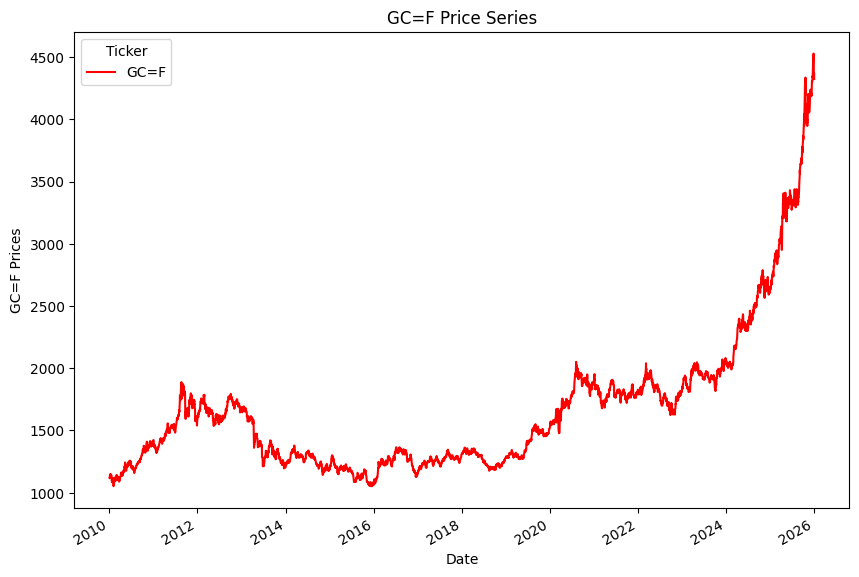

In [6]:
data.Close.plot(figsize=(10, 7), color='r')
plt.ylabel("{} Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()


<Axes: ylabel='Count'>

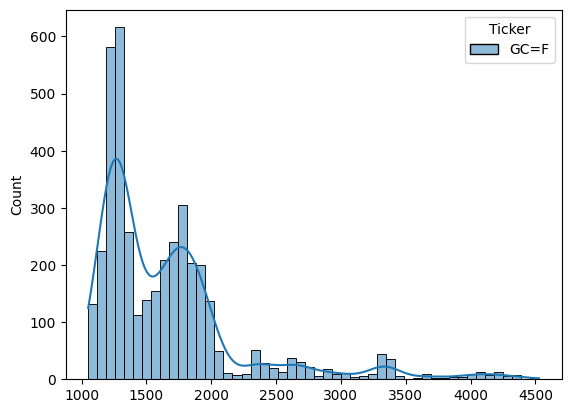

In [8]:
sns.histplot(data["Close"], kde=True)


<Axes: ylabel='Count'>

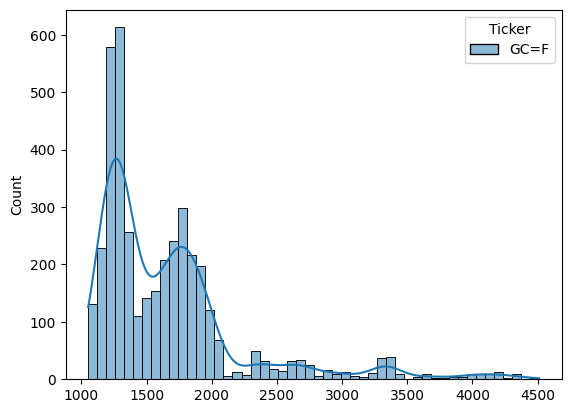

In [9]:
sns.histplot(data["Open"], kde=True)


<Axes: ylabel='Count'>

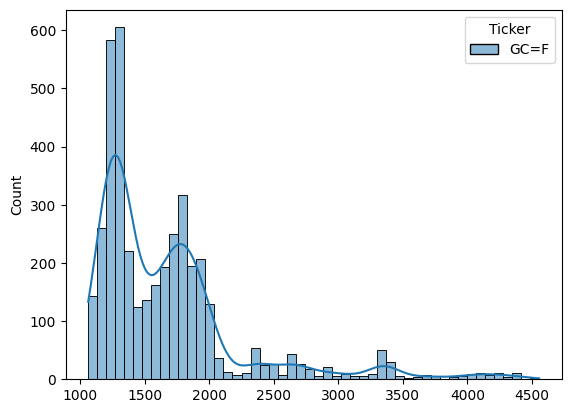

In [10]:
sns.histplot(data["High"], kde=True)

In [11]:
x = data.drop("Close" , axis = 1)
y = data["Close"]

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3218, 4)
(805, 4)
(3218, 1)
(805, 1)


In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred1 = lr.predict(x_test)


In [13]:
pred1

array([[1076.04280121],
       [1693.9008938 ],
       [1292.15481264],
       [1265.6298131 ],
       [1194.13901271],
       [1080.41884606],
       [1198.11602719],
       [1294.75325907],
       [1578.35966074],
       [1856.35537619],
       [1187.27763928],
       [2190.99616774],
       [1211.82103336],
       [2041.9549986 ],
       [2628.06687068],
       [1160.12854243],
       [1317.30588305],
       [1715.91562064],
       [1662.04859194],
       [3337.62141842],
       [1630.28879436],
       [1266.8533114 ],
       [1210.20223047],
       [1787.82465722],
       [1805.55627035],
       [1292.82248355],
       [1314.08899315],
       [1200.64297486],
       [1272.88941702],
       [1345.15606841],
       [1864.67524507],
       [1780.58396723],
       [1933.39604669],
       [1519.81227685],
       [1289.0856055 ],
       [1650.87376852],
       [1830.53749901],
       [1691.83940918],
       [4329.560441  ],
       [1289.45355313],
       [1659.77164173],
       [1233.221

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

def calculate_metrics(y_test, y_pred):
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scors = r2_score(y_test, y_pred)

    print("MSE:- ", mse)
    print("RMSE:- ", rmse)
    print("R2_score:- ", r2_scors)

calculate_metrics(y_test, pred1)


MSE:-  39.757592913865665
RMSE:-  6.305362234944608
R2_score:-  0.9998837436515873


In [15]:
from sklearn.linear_model import Lasso , Ridge

la = Lasso().fit(x_train , y_train)
ri = Ridge().fit(x_train , y_train)

la_p = la.predict(x_test)
ri_p = ri.predict(x_test)


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.318500e+05, tolerance: 1.103e+05
  model = cd_fast.enet_coordinate_descent(


In [16]:
calculate_metrics(y_test , la_p)

MSE:-  67.54943754054383
RMSE:-  8.218846484789934
R2_score:-  0.9998024767001661


In [17]:
calculate_metrics(y_test ,ri_p)

MSE:-  39.757502802621254
RMSE:-  6.305355089336464
R2_score:-  0.9998837439150842


In [19]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(svr, param_grid, refit=True, verbose=3)
grid.fit(x_train , y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.104 total time=   0.2s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.057 total time=   0.2s


...

[CV 4/5] END ..C=1000, gamma=0.0001, kernel=rbf;, score=0.745 total time=   5.1s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END ..C=1000, gamma=0.0001, kernel=rbf;, score=0.689 total time=   4.9s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is u

In [20]:
svr = SVR(C=1000, gamma=0.0001, kernel='rbf') 

svr.fit(x_train, y_train)

svr_pred = svr.predict(x_test)

c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [21]:
calculate_metrics(y_test, svr_pred)

MSE:-  81566.0874309081
RMSE:-  285.5977721042447
R2_score:-  0.7614902013918088


In [22]:
import joblib

joblib.dump(ri, "gold_model.pkl")

ridge_from_joblib = model = joblib.load("gold_model.pkl")

In [23]:
model = joblib.load("gold_model.pkl")

In [24]:
prediction = model.predict(x_test)

print(prediction[:5])

[1076.04278475 1693.90086955 1292.15481548 1265.62981838 1194.13902817]


In [25]:
print("Predicted:", prediction[:5])
print("Actual:   ", y_test[:5].values)

Predicted: [1076.04278475 1693.90086955 1292.15481548 1265.62981838 1194.13902817]
Actual:    [[1076.30004883]
 [1701.59997559]
 [1293.30004883]
 [1271.59997559]
 [1200.40002441]]
